# Heart Failure Clinical Records - Classification ML Assignment

## Import Libraries

In [1]:
# Basic libraries for data handling
import pandas as pd
import numpy as np

# Libraries for plotting/charts
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)

# Library to balance imbalanced dataset
from imblearn.over_sampling import SMOTE

# Just for nicer looking charts
sns.set_style("whitegrid")
%matplotlib inline


## Load Dataset

In [2]:
df = pd.read_csv("heart_failure.csv")
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (299, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


## Data Info

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [4]:
df.describe()


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


## Check Missing Values

In [5]:
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({"Missing Count": missing_values, "Missing %": missing_percent})
missing_df[missing_df["Missing Count"] > 0]


,Missing Count,Missing %


## Fill Null Values

In [6]:
# Get list of columns that have missing values
cols_with_null = df.columns[df.isnull().any()]

# Fill each missing value with the median of that column (if any are found)
for col in cols_with_null:
    df[col] = df[col].fillna(df[col].median())

# Confirm that there are no missing values left
print("Total missing values after filling:", df.isnull().sum().sum())


Total missing values after filling: 0


## Check and Remove Duplicates

In [7]:
print("Number of duplicate rows before removing:", df.duplicated().sum())

# Remove duplicate rows (if any) and reset the index
df = df.drop_duplicates().reset_index(drop=True)

print("Number of duplicate rows after removing:", df.duplicated().sum())
print("New shape of dataset:", df.shape)


Number of duplicate rows before removing: 0
Number of duplicate rows after removing: 0
New shape of dataset: (299, 13)


## One Hot Encoding

In [8]:
# Check which columns are categorical (text/object type)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns found:", categorical_cols)

# All columns in this dataset (anaemia, diabetes, sex, smoking, high_blood_pressure, etc.)
# are already numeric (0/1 flags), so there is nothing left to one hot encode.
# We still apply get_dummies here so the code works automatically even if
# a categorical column is found.
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df.head()


Categorical columns found: []


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


## Exploratory Data Analysis

### Target Column Distribution

/tmp/ipykernel_479/3563583403.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='DEATH_EVENT', data=df, palette='Set2')


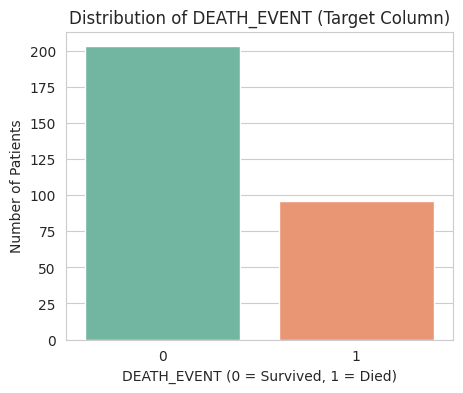

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64


In [9]:
plt.figure(figsize=(5,4))
sns.countplot(x='DEATH_EVENT', data=df, palette='Set2')
plt.title("Distribution of DEATH_EVENT (Target Column)")
plt.xlabel("DEATH_EVENT (0 = Survived, 1 = Died)")
plt.ylabel("Number of Patients")
plt.show()

print(df['DEATH_EVENT'].value_counts())


### Age Distribution

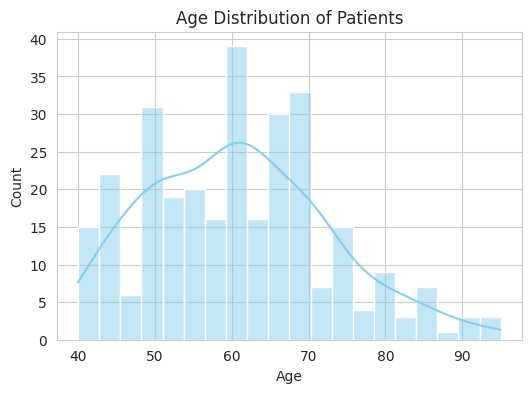

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


### Ejection Fraction vs Death Event

/tmp/ipykernel_479/1498730346.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DEATH_EVENT', y='ejection_fraction', data=df, palette='Set2')


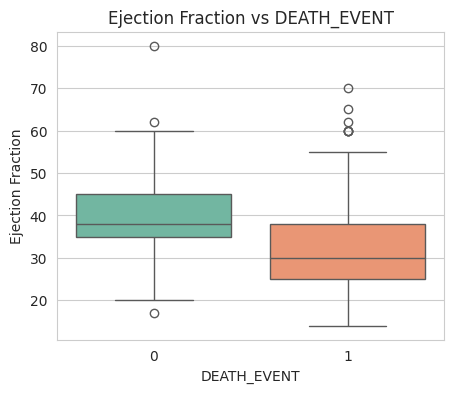

In [11]:
plt.figure(figsize=(5,4))
sns.boxplot(x='DEATH_EVENT', y='ejection_fraction', data=df, palette='Set2')
plt.title("Ejection Fraction vs DEATH_EVENT")
plt.xlabel("DEATH_EVENT")
plt.ylabel("Ejection Fraction")
plt.show()


### Smoking vs Death Event

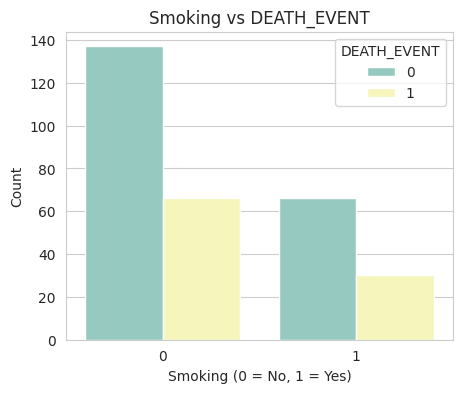

In [12]:
plt.figure(figsize=(5,4))
sns.countplot(x='smoking', hue='DEATH_EVENT', data=df, palette='Set3')
plt.title("Smoking vs DEATH_EVENT")
plt.xlabel("Smoking (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


### Correlation Heatmap

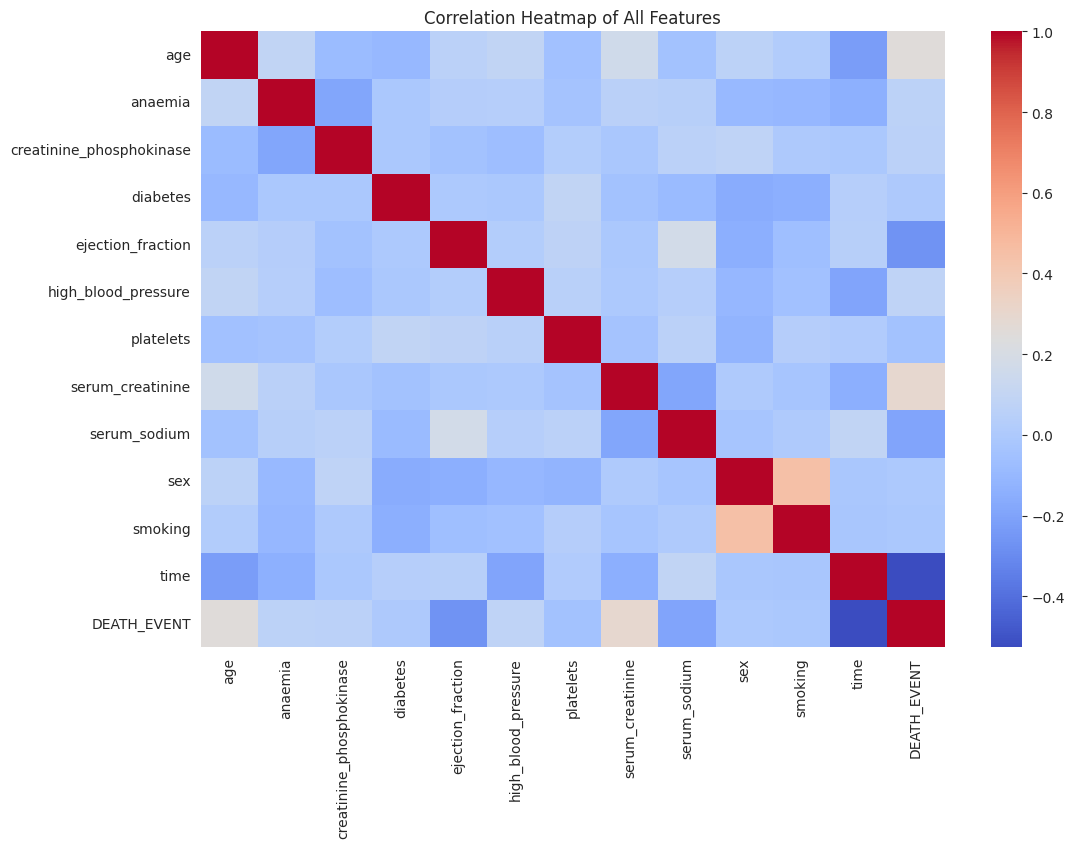

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap of All Features")
plt.show()


### Serum Creatinine vs Death Event

/tmp/ipykernel_479/1992815074.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DEATH_EVENT', y='serum_creatinine', data=df, palette='Set2')


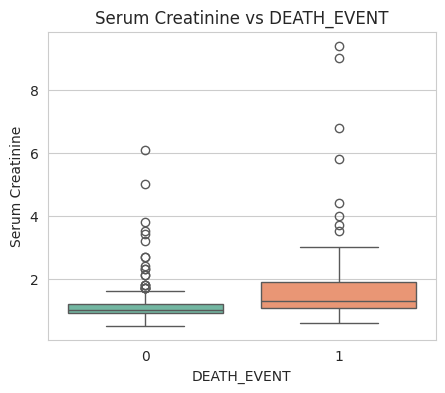

In [14]:
plt.figure(figsize=(5,4))
sns.boxplot(x='DEATH_EVENT', y='serum_creatinine', data=df, palette='Set2')
plt.title("Serum Creatinine vs DEATH_EVENT")
plt.xlabel("DEATH_EVENT")
plt.ylabel("Serum Creatinine")
plt.show()


## Features and Target

In [15]:
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (299, 12)
Shape of y: (299,)


## Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (239, 12)
Testing set shape: (60, 12)


## Feature Scaling

In [17]:
scaler = StandardScaler()

# Fit the scaler ONLY on training data, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling done successfully!")


Feature scaling done successfully!


## Handle Imbalanced Dataset (SMOTE)

In [18]:
print("Before SMOTE:", y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE:", y_train_bal.value_counts().to_dict())


Before SMOTE: {0: 162, 1: 77}
After SMOTE: {0: 162, 1: 162}


## Model 1: Logistic Regression

In [19]:
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_bal, y_train_bal)

# Predict on test data
y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression model trained successfully!")


Logistic Regression model trained successfully!


### Evaluation

In [20]:
acc_log = accuracy_score(y_test, y_pred_log)
prec_log = precision_score(y_test, y_pred_log)
rec_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print("Accuracy :", round(acc_log, 3))
print("Precision:", round(prec_log, 3))
print("Recall   :", round(rec_log, 3))
print("F1-Score :", round(f1_log, 3))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))


Accuracy : 0.8
Precision: 0.733
Recall   : 0.579
F1-Score : 0.647

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.90      0.86        41
           1       0.73      0.58      0.65        19

    accuracy                           0.80        60
   macro avg       0.78      0.74      0.75        60
weighted avg       0.79      0.80      0.79        60



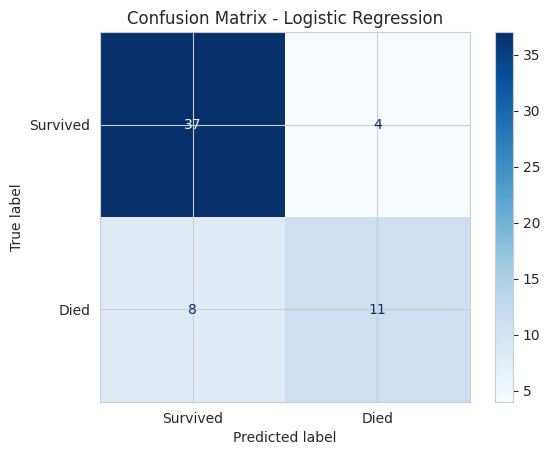

In [21]:
cm_log = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['Survived', 'Died'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


## Model 2: Random Forest

In [22]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train_bal, y_train_bal)

# Predict on test data
y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest model trained successfully!")


Random Forest model trained successfully!


### Evaluation

In [23]:
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Accuracy :", round(acc_rf, 3))
print("Precision:", round(prec_rf, 3))
print("Recall   :", round(rec_rf, 3))
print("F1-Score :", round(f1_rf, 3))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))


Accuracy : 0.8
Precision: 0.684
Recall   : 0.684
F1-Score : 0.684

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.85      0.85        41
           1       0.68      0.68      0.68        19

    accuracy                           0.80        60
   macro avg       0.77      0.77      0.77        60
weighted avg       0.80      0.80      0.80        60



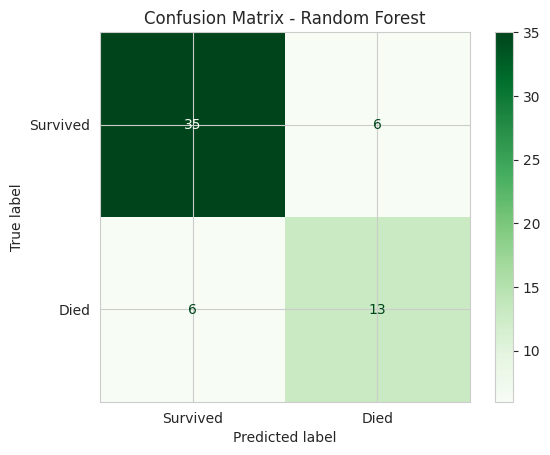

In [24]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Survived', 'Died'])
disp.plot(cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.show()


## Feature Importance

/tmp/ipykernel_479/3106992421.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


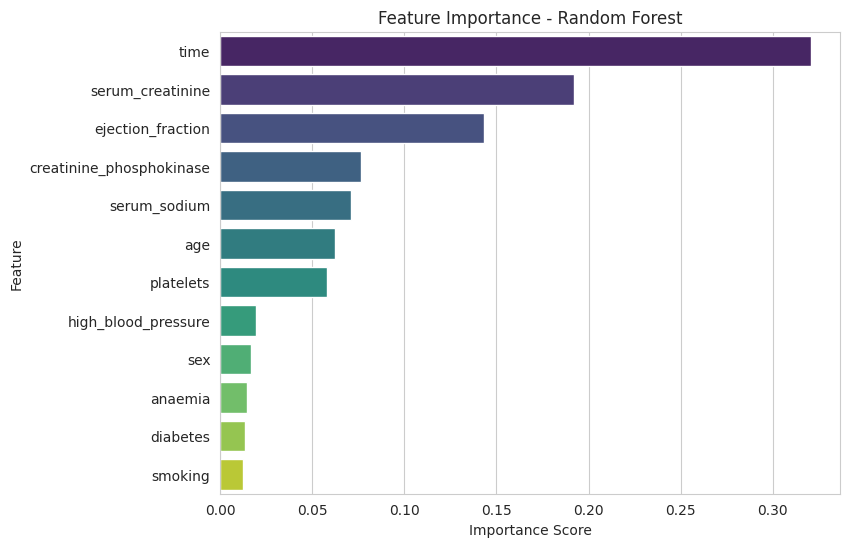

In [25]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


## Compare Both Models

In [26]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [acc_log, acc_rf],
    'Precision': [prec_log, prec_rf],
    'Recall': [rec_log, rec_rf],
    'F1-Score': [f1_log, f1_rf]
})

results


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8,0.733333,0.578947,0.647059
1,Random Forest,0.8,0.684211,0.684211,0.684211


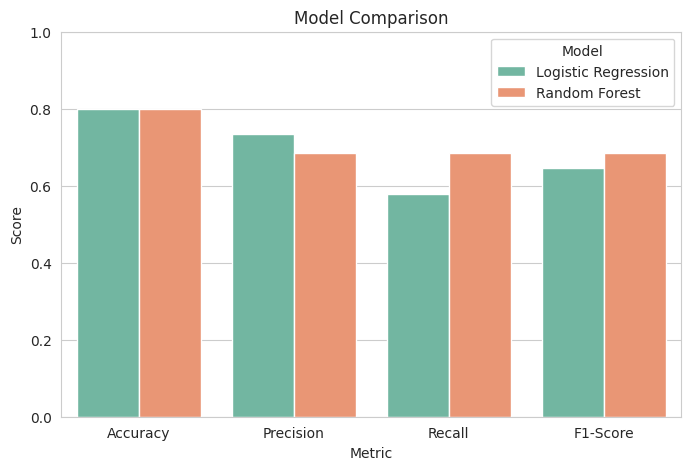

Best model based on Accuracy: Logistic Regression


In [27]:
results_melted = results.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(8,5))
sns.barplot(x='Metric', y='Score', hue='Model', data=results_melted, palette='Set2')
plt.title("Model Comparison")
plt.ylim(0, 1)
plt.show()

best_model_name = results.loc[results['Accuracy'].idxmax(), 'Model']
print("Best model based on Accuracy:", best_model_name)


## Conclusion